# Full Bayesian Operator Inference: Cubic Heat Equation

**Workflow:**
1. Generate training data (multiple ICs) and fit POD basis
2. Grid search for prior operator
3. Fit GP hyperparameters
4. Run Bayesian inference (SVI/MCMC)
5. Evaluate and visualize results (including test IC)

## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro

from core import (
    grid_search_prior_operator,
    fit_gp_hyperparameters_mle,
    build_bayesian_opinf_model,
    run_svi,
    run_mcmc,
    generate_rom_predictions,
    plot_gp_fit,
    run_diagnostics,
    DataScaler,
)
from config import (
    FullOrderModel, Basis,
    input_func_factory, input_parameters, test_parameters,
    time_domain, initial_conditions,
)

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAHBN"       # OpInf operator structure (with inputs)
NUM_MODES = 5            # POD modes to retain
NUM_TRAIN_ICS = 5         # Number of training ICs to use

# Time domain settings
TRAINING_SPAN = (0, 1.0)  # Subset of time_domain used for training
PREDICTION_SPAN = (0, 2.0) # Full time domain for ROM evaluation (includes extrapolation)

# Data generation settings
NUM_SAMPLES = 65          # Number of uniformly subsampled training snapshots per trajectory
NOISE_LEVEL = 0.01       # Noise as fraction of signal (0 = no noise)
NUM_EVAL_POINTS = 150    # Set to None to use the original training times (no densification)

# Data scaling
USE_SCALED_DATA = False   # Standardize POD coefficients for GP fitting

# Inference settings
RUN_SVI = True
RUN_MCMC = False           # More expensive, optional
USE_DETERMINISTIC_INIT_FOR_MCMC = False  # Initialize MCMC from MAP estimate (requires RUN_SVI=False)
USE_SVI_FOR_MCMC_INIT = True  # Initialize MCMC from SVI result (requires RUN_SVI=True)
GUIDE = numpyro.infer.autoguide.AutoDelta  # Guide for SVI; ignored if not using SVI

# Hyperparameters
GAMMA = 1e0      # Operator prior variance
GAMMA2 = 1e0     # ODE constraint stiffness
GAMMA3 = 5e-1      # Operator prior variance for MCMC (if different from SVI)
GAMMA4 = 5e-1     # ODE constraint stiffness for MCMC (if different from SVI)

## 2. Generate Training Data

In [3]:
# Select training and test parameters
train_params = input_parameters[:NUM_TRAIN_ICS]
test_params = test_parameters

print(f"Training parameters: {train_params}")
print(f"Test parameters: {test_params}")

# Build the full prediction time domain from config
# time_domain from config.py spans [0, 2] — filter it to PREDICTION_SPAN
time_domain_full = time_domain[
    (time_domain >= PREDICTION_SPAN[0]) & (time_domain <= PREDICTION_SPAN[1])
]

# Generate training trajectories — solve on full prediction domain for truth
all_true_states = []
all_inputs_full = []

for params in train_params:
    fom = FullOrderModel(params)
    states = fom.solve(initial_conditions, time_domain_full)
    ifunc = input_func_factory(params)

    all_true_states.append(states)
    all_inputs_full.append(ifunc(time_domain_full))

# Subsample uniformly from TRAINING_SPAN only
time_domain_train = time_domain_full[
    (time_domain_full >= TRAINING_SPAN[0]) & (time_domain_full <= TRAINING_SPAN[1])
]
sample_indices_in_train = np.linspace(0, len(time_domain_train) - 1, NUM_SAMPLES, dtype=int)
time_sampled = time_domain_train[sample_indices_in_train]

# Map sampled times back to indices in time_domain_full (for extracting true states)
sample_indices_in_full = np.array([
    np.argmin(np.abs(time_domain_full - t)) for t in time_sampled
])

all_snapshots = []
all_inputs = []
for i in range(NUM_TRAIN_ICS):
    # Add noise to subsampled snapshots (from full-resolution truth)
    noisy = FullOrderModel.noise(all_true_states[i][:, sample_indices_in_full], NOISE_LEVEL)
    all_snapshots.append(noisy)
    all_inputs.append(all_inputs_full[i][:, sample_indices_in_full])

# Stack all training data
snapshots_train = np.hstack(all_snapshots)
inputs_train = np.hstack(all_inputs)

print(f"\nTraining span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Noise level: {NOISE_LEVEL:.1%}")
print(f"Samples per trajectory: {NUM_SAMPLES}")
print(f"Full time domain points: {len(time_domain_full)}")
print(f"Training snapshots (noisy, subsampled): {snapshots_train.shape}")
print(f"Training inputs: {inputs_train.shape}")
print(f"Training time: [{time_sampled[0]:.4f}, {time_sampled[-1]:.4f}]")

Training parameters: ((-2, 0), (-1, -2), (0, 1), (1, -1), (2, 2))
Test parameters: (1.5, 0.5)

Training span: [0, 1.0]
Prediction span: [0, 2.0]
Noise level: 1.0%
Samples per trajectory: 65
Full time domain points: 500
Training snapshots (noisy, subsampled): (500, 325)
Training inputs: (2, 325)
Training time: [0.0000, 0.9980]


In [4]:
# Generate test trajectory (on full prediction domain)
fom_test = FullOrderModel(test_params)
snapshots_test = fom_test.solve(initial_conditions, time_domain_full)
test_input_func = input_func_factory(test_params)
inputs_test = test_input_func(time_domain_full)

print(f"Test snapshots: {snapshots_test.shape}")
print(f"Test time span: [{time_domain_full[0]:.4f}, {time_domain_full[-1]:.4f}]")

Test snapshots: (500, 500)
Test time span: [0.0000, 2.0000]


In [5]:
# Fit POD basis (with lifting: q, q^2)
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_train)

snapshots_compressed = basis.compress(snapshots_train)
snapshots_test_compressed = basis.compress(snapshots_test)

print(f"Compressed shape: {snapshots_compressed.shape}")
print(f"Test compressed shape: {snapshots_test_compressed.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

Compressed shape: (5, 325)
Test compressed shape: (5, 500)
Cumulative energy: 99.4718%


In [6]:
# For grid search and GP fitting, use first trajectory only.
snapshots_first = snapshots_train[:, :NUM_SAMPLES]
snapshots_comp_first = snapshots_compressed[:, :NUM_SAMPLES]
inputs_first = inputs_train[:, :NUM_SAMPLES]

print(f"Training samples per traj: {NUM_SAMPLES}")
print(f"Total training samples: {snapshots_compressed.shape[1]}")
print(f"Training time span: [{time_sampled[0]:.4f}, {time_sampled[-1]:.4f}]")

# Set up evaluation time domains for plotting
NUM_REGRESSION_POINTS = 150
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)

print(f"Eval training domain: [{time_domain_eval_training[0]:.4f}, {time_domain_eval_training[-1]:.4f}] ({len(time_domain_eval_training)} pts)")
print(f"Eval prediction domain: [{time_domain_eval_prediction[0]:.4f}, {time_domain_eval_prediction[-1]:.4f}] ({len(time_domain_eval_prediction)} pts)")

Training samples per traj: 65
Total training samples: 325
Training time span: [0.0000, 0.9980]
Eval training domain: [0.0000, 1.0000] (150 pts)
Eval prediction domain: [0.0000, 2.0000] (150 pts)


## 3a. Data Scaling (Optional)

When `USE_SCALED_DATA=True`, each POD mode is standardized to zero mean and unit variance before GP fitting. This improves GP hyperparameter learning and numerical conditioning.

The scaling is handled consistently:
1. GPs are fitted on scaled data
2. In the Bayesian model: latent states live in scaled space → transformed to original for operator dynamics → derivatives scaled back for comparison with GP derivatives
3. Posterior predictions are inverse-transformed back to original space

In [7]:
# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_first)
    training_data = data_scaler.transform(snapshots_comp_first)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_first
    print("Scaling disabled: using raw POD coefficients")

Scaling disabled: using raw POD coefficients


## 3. Grid Search for Prior Operator

In [8]:
# Find best deterministic operator via regularization grid search
# Use first training trajectory for initial search
first_input_func = input_func_factory(train_params[0])

result = grid_search_prior_operator(
    basis=basis,
    time_domain_sampled=time_sampled,
    snapshots_sampled=snapshots_first,
    snapshots_compressed=snapshots_comp_first,
    operators=OPERATORS,
    inputs=inputs_first,
    input_func=first_input_func,
    verbose=True
)

prior_operator = result.operator
rom = result.rom
print(f"\nPrior operator shape: {prior_operator.shape}")

Testing 12 regularization values...
  reg=1.0e-08: UNSTABLE
  reg=1.0e-06: UNSTABLE
  reg=1.0e-04: UNSTABLE
  reg=1.0e-02: UNSTABLE
  reg=1.0e-01: STABLE, error=0.015188
  reg=5.0e-01: STABLE, error=0.011815
  reg=1.0e+00: STABLE, error=0.017163
  reg=5.0e+00: STABLE, error=0.267550
  reg=1.0e+01: STABLE, error=0.850801
  reg=1.0e+02: STABLE, error=1.601721
  reg=1.0e+03: STABLE, error=1.575082
  reg=1.0e+04: STABLE, error=1.574904

✅ Best reg: 5.0e-01, error: 0.011815

Prior operator shape: (5, 33)


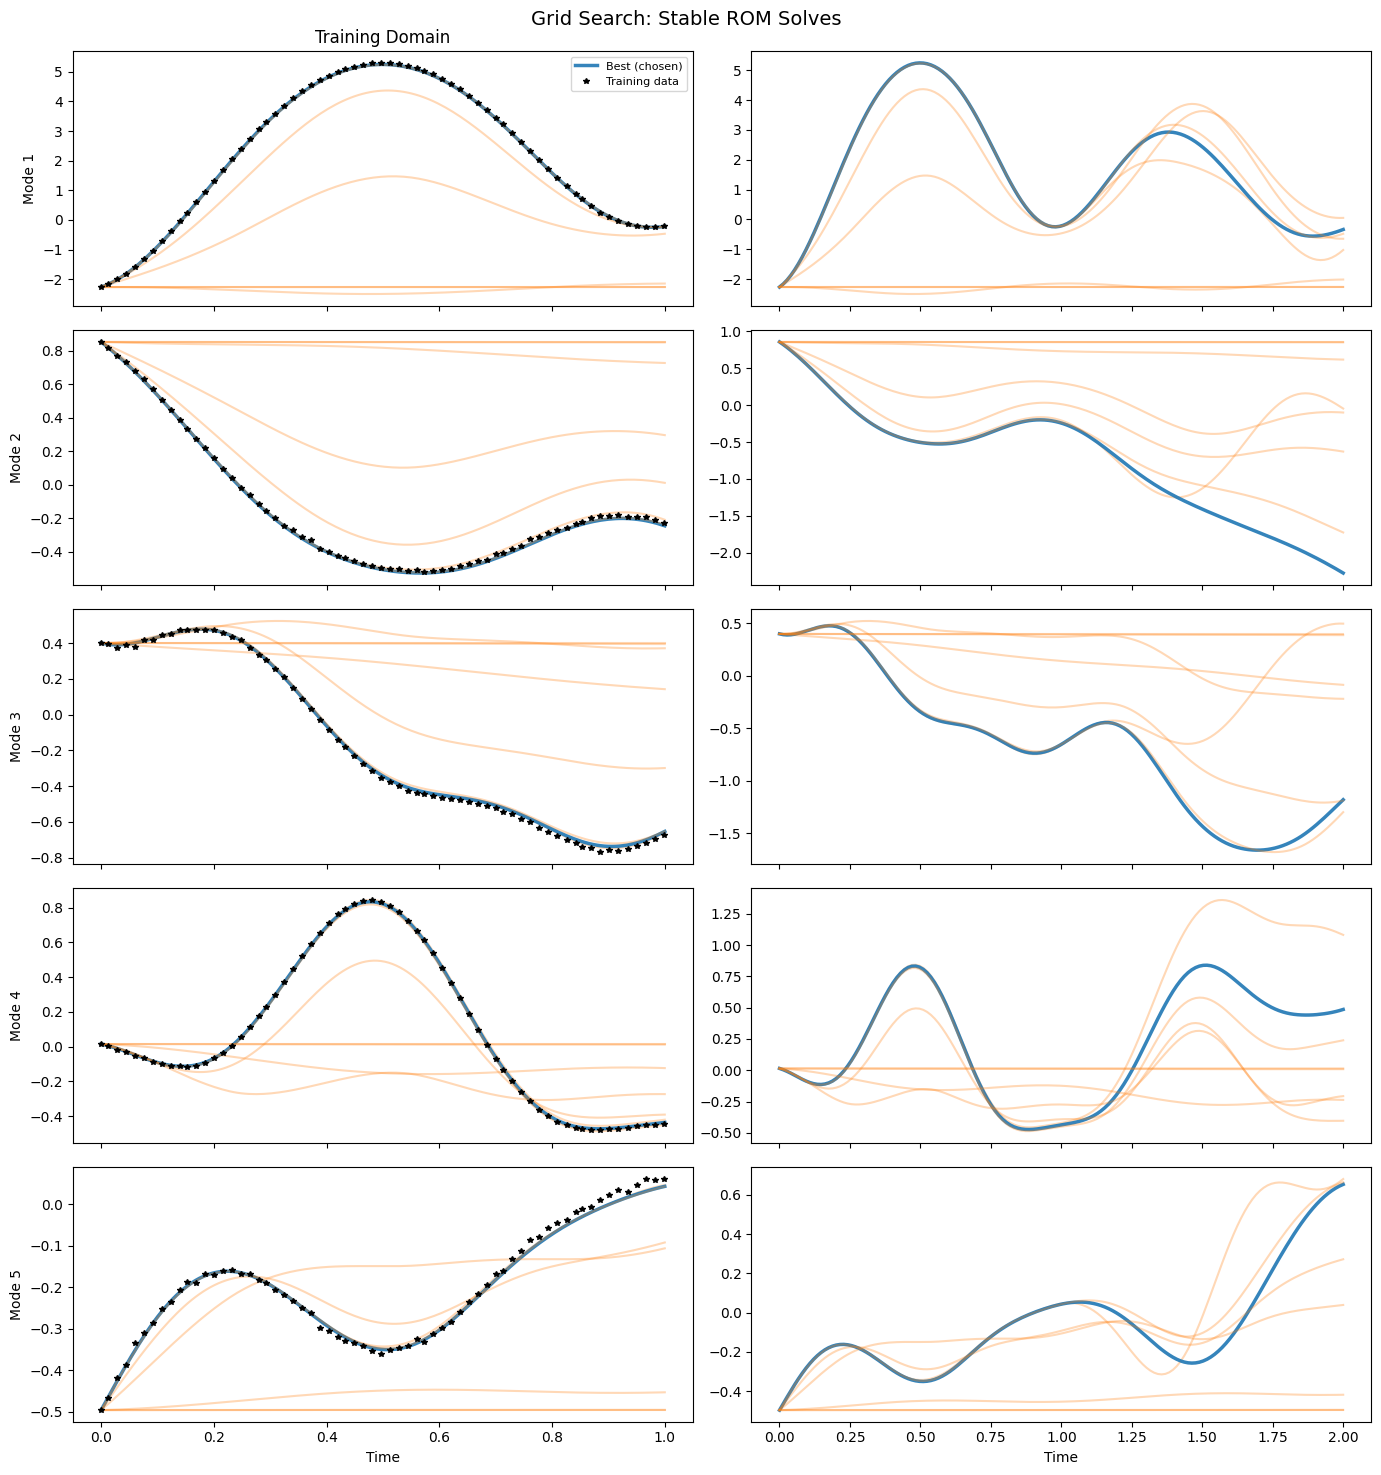

In [9]:
# Debug: Plot all stable deterministic ROM solves from grid search
from heat_plotter import plot_heat_grid_search

first_input_func = input_func_factory(train_params[0])

fig, axes = plot_heat_grid_search(
    grid_search_result=result,
    snapshots_compressed=snapshots_comp_first,
    time_sampled=time_sampled,
    time_eval_training=time_domain_eval_training,
    time_eval_prediction=time_domain_eval_prediction,
    num_modes=NUM_MODES,
    input_func=first_input_func,
)
plt.show()

## 4. Fit GP Hyperparameters

In [10]:
# Fit GP for each mode via MLE — per trajectory
# We fit separate GPs for each IC so the Bayesian model gets trajectory-specific
# derivative information for the ODE constraints.

all_Ls, all_Vs, all_Ns, all_gp_models = [], [], [], []
all_snapshots_comp = []

for ic_idx in range(NUM_TRAIN_ICS):
    s, e = ic_idx * NUM_SAMPLES, (ic_idx + 1) * NUM_SAMPLES
    snap_ic = snapshots_compressed[:, s:e]
    data_ic = data_scaler.transform(snap_ic) if USE_SCALED_DATA else snap_ic
    all_snapshots_comp.append(data_ic)

    print(f"\n--- IC {ic_idx+1} ({train_params[ic_idx]}) ---")
    Ls_ic, Vs_ic, Ns_ic, gps_ic = fit_gp_hyperparameters_mle(
        time_domain=time_sampled,
        snapshots=data_ic,
        verbose=True
    )
    all_Ls.append(Ls_ic)
    all_Vs.append(Vs_ic)
    all_Ns.append(Ns_ic)
    all_gp_models.append(gps_ic)

# Keep first-IC references for backward compat
Ls, Vs, Ns, gp_models = all_Ls[0], all_Vs[0], all_Ns[0], all_gp_models[0]
print(f"\nFitted GPs for {NUM_TRAIN_ICS} trajectories × {NUM_MODES} modes")


--- IC 1 ((-2, 0)) ---
Fitting GP hyperparameters via MLE...
  L=0.2575, V=8.4082, N=0.000017
  Mode 0: L=0.2575, V=8.4082, N=0.000017
  L=0.2921, V=0.3568, N=0.000027
  Mode 1: L=0.2921, V=0.3568, N=0.000027
  L=0.2179, V=0.4662, N=0.000021
  Mode 2: L=0.2179, V=0.4662, N=0.000021
  L=0.2277, V=0.3030, N=0.000003
  Mode 3: L=0.2277, V=0.3030, N=0.000003
  L=0.2824, V=0.2212, N=0.000027
  Mode 4: L=0.2824, V=0.2212, N=0.000027

--- IC 2 ((-1, -2)) ---
Fitting GP hyperparameters via MLE...
  L=0.1931, V=3.3391, N=0.000040
  Mode 0: L=0.1931, V=3.3391, N=0.000040
  L=0.1714, V=6.0800, N=0.000022
  Mode 1: L=0.1714, V=6.0800, N=0.000022
  L=0.2161, V=0.1565, N=0.000033
  Mode 2: L=0.2161, V=0.1565, N=0.000033
  L=0.1597, V=0.0384, N=0.000003
  Mode 3: L=0.1597, V=0.0384, N=0.000003
  L=0.1667, V=0.1150, N=0.000023
  Mode 4: L=0.1667, V=0.1150, N=0.000023

--- IC 3 ((0, 1)) ---
Fitting GP hyperparameters via MLE...
  L=0.2705, V=4.5854, N=0.000048
  Mode 0: L=0.2705, V=4.5854, N=0.000048


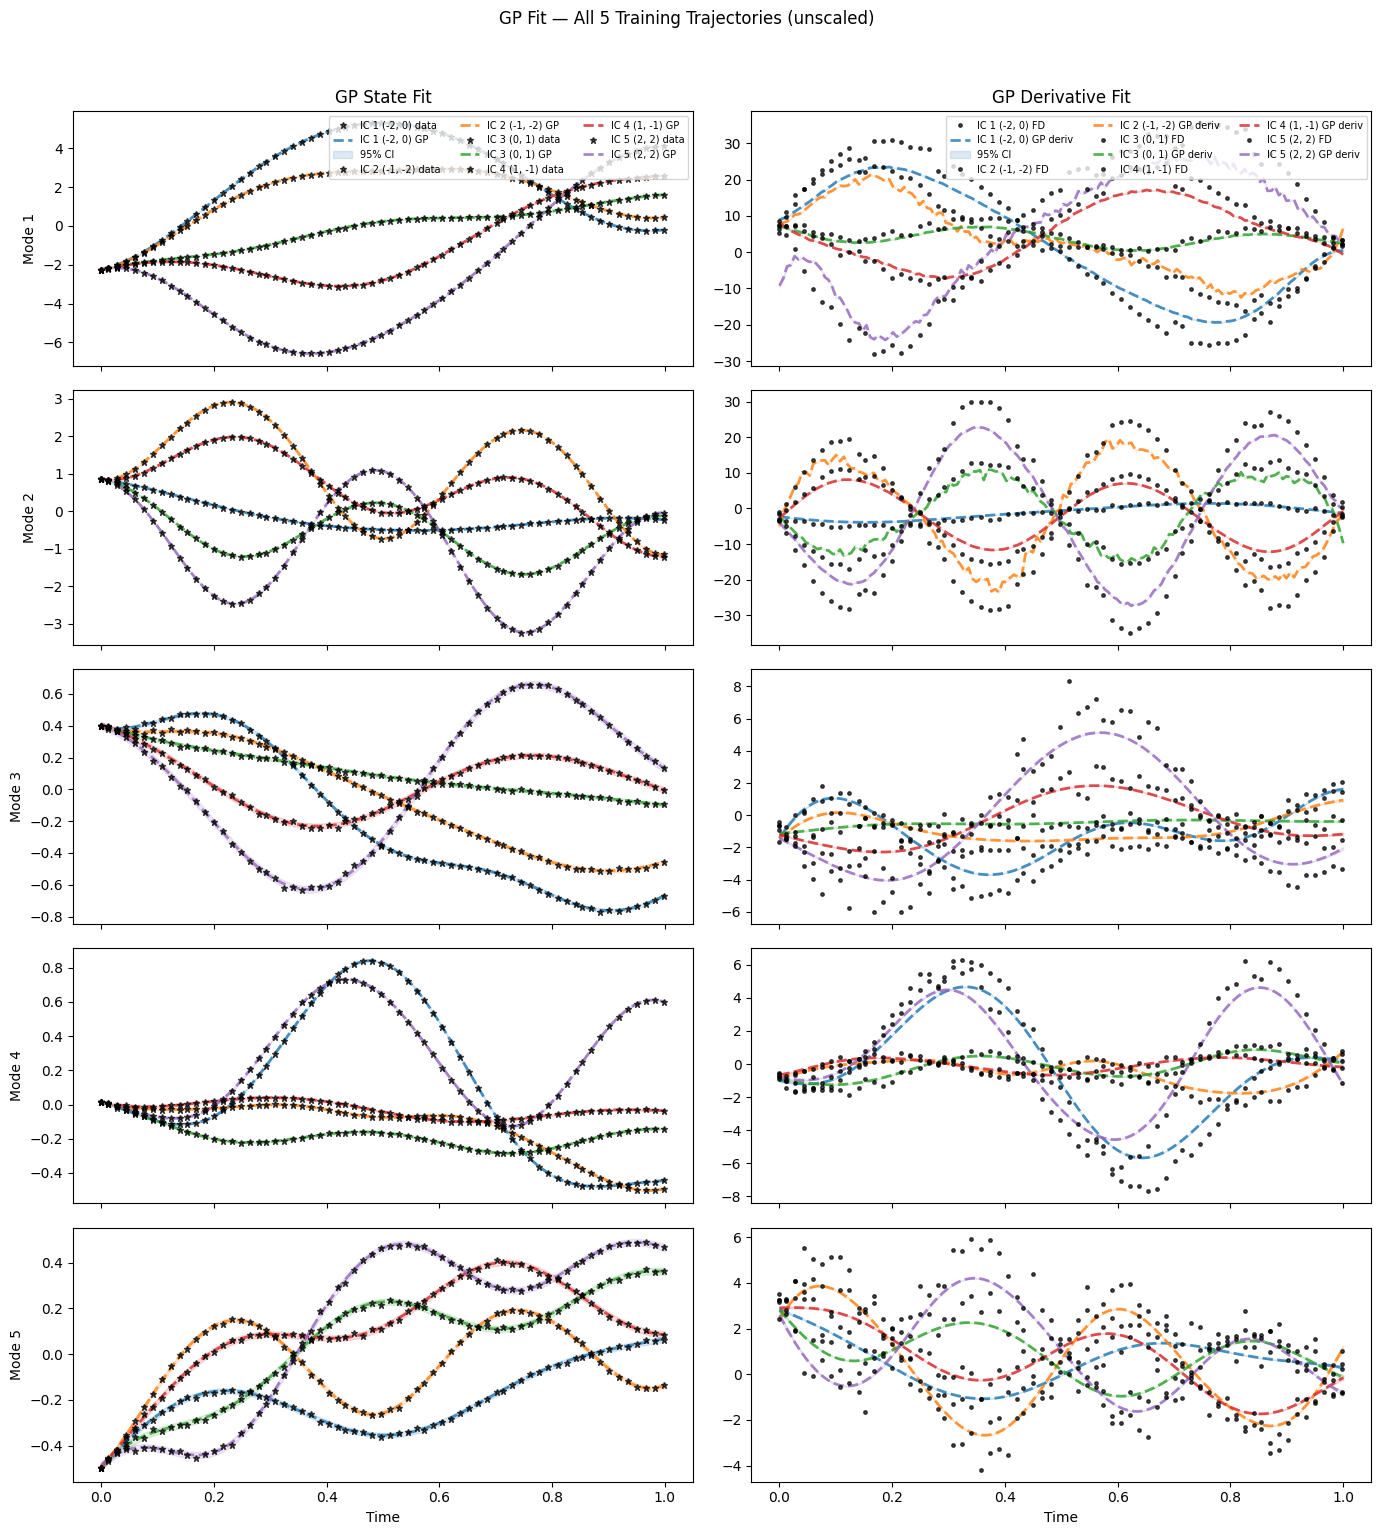

In [11]:
# Visualize GP fit quality for ALL training trajectories
fig, axes = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=all_snapshots_comp[0],
    time_sampled=time_sampled,
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
    # Multi-trajectory overlay
    all_snapshots_compressed=all_snapshots_comp,
    all_gp_models=all_gp_models,
    all_lengthscales=all_Ls,
    all_variances=all_Vs,
    trajectory_labels=[f"IC {i+1} {train_params[i]}" for i in range(NUM_TRAIN_ICS)],
)
plt.suptitle(f"GP Fit — All {NUM_TRAIN_ICS} Training Trajectories ({'scaled' if USE_SCALED_DATA else 'unscaled'})", y=1.02)
plt.show()

## 5. Bayesian Inference

In [12]:
# Build evaluation time grid (densified via GP if NUM_EVAL_POINTS is set)
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(time_sampled[0], time_sampled[-1], NUM_EVAL_POINTS)
    print(f"GP densification: evaluating ODE constraints at {NUM_EVAL_POINTS} points "
          f"(vs {len(time_sampled)} training samples)")
else:
    time_eval = time_sampled
    print(f"No densification: evaluating at {len(time_sampled)} training times")

# Precompute GP mean predictions at evaluation points — per IC
all_Xs_means = []
all_inputs_eval = []
for ic_idx in range(NUM_TRAIN_ICS):
    Xs_means_ic = np.array([
        all_gp_models[ic_idx][i].predict(time_eval[:, None], return_std=False)
        for i in range(NUM_MODES)
    ])
    all_Xs_means.append(Xs_means_ic)
    
    ic_input_func = input_func_factory(train_params[ic_idx])
    all_inputs_eval.append(np.array(ic_input_func(time_eval)))

# Keep first-IC references for backward compat
Xs_means = all_Xs_means[0]
inputs_eval = all_inputs_eval[0]
first_input_func = input_func_factory(train_params[0])

print(f"Prepared GP predictions for {NUM_TRAIN_ICS} trajectories")
print(f"  Xs_means per IC shape: {all_Xs_means[0].shape}")
print(f"  inputs_eval per IC shape: {all_inputs_eval[0].shape}")

# Build Bayesian model with multi-IC ODE constraints
bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=prior_operator if not USE_DETERMINISTIC_INIT_FOR_MCMC else jnp.zeros_like(prior_operator),
    rom=rom,
    Ls_means=all_Ls,
    Vs_means=all_Vs,
    time_domain_sampled=[time_sampled] * NUM_TRAIN_ICS,
    snapshots=all_snapshots_comp,
    Xs_means=all_Xs_means,
    Ns_means=all_Ns,
    inputs_eval=all_inputs_eval,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
)
print(f"Bayesian model built with {NUM_TRAIN_ICS} IC(s) × {NUM_MODES} mode(s) "
      f"= {NUM_TRAIN_ICS * NUM_MODES} ODE constraint terms")

GP densification: evaluating ODE constraints at 150 points (vs 65 training samples)
Prepared GP predictions for 5 trajectories
  Xs_means per IC shape: (5, 150)
  inputs_eval per IC shape: (2, 150)
Bayesian model built with 5 IC(s) × 5 mode(s) = 25 ODE constraint terms


In [13]:
# Run SVI
if RUN_SVI:
    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=50000,
        learning_rate=1e-1,
        verbose=True,
        guide=GUIDE
    )
    samples = svi_result.samples
    
    # Extract operator for potential MCMC initialization
    # AutoDelta stores as 'O_auto_loc', MCMC stores as 'O'
    O_key = next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        # Get point estimate (mean over samples or first sample)
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")
    
    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

Running SVI (gamma=1.0, gamma2=1.0)...


  0%|          | 105/50000 [00:45<6:01:49,  2.30it/s]


KeyboardInterrupt: 

### 5a. SVI Results

In [ ]:
import importlib, heat_plotter
importlib.reload(heat_plotter)
from heat_plotter import HeatPlotter, compute_trajectory_errors, plot_operator_comparison

def _build_trajectories():
    """Build trajectory dicts for all training ICs + test IC."""
    trajs = []
    for ic_idx in range(NUM_TRAIN_ICS):
        s, e = ic_idx * NUM_SAMPLES, (ic_idx + 1) * NUM_SAMPLES
        trajs.append({
            'q0': snapshots_compressed[:, s],
            'input_func': input_func_factory(train_params[ic_idx]),
            'snapshots': snapshots_compressed[:, s:e],
            'time_snapshots': time_sampled,
            'true_compressed': basis.compress(all_true_states[ic_idx]),
            'time_true': time_domain_full,
            'label': f'Train {ic_idx+1} {train_params[ic_idx]}',
        })
    trajs.append({
        'q0': snapshots_test_compressed[:, 0],
        'input_func': input_func_factory(test_params),
        'snapshots': None,
        'time_snapshots': None,
        'true_compressed': snapshots_test_compressed,
        'time_true': time_domain_full,
        'label': f'Test {test_params}',
    })
    return trajs

def _evaluate_and_plot(stage_samples, stage_name):
    """Generate predictions, heatmap, and multi-trajectory plot for a given stage."""
    Os_stage, Xs_stage, rom_solves_stage = generate_rom_predictions(
        samples=stage_samples, rom=rom,
        snapshots_compressed=snapshots_comp_first,
        time_eval=time_domain_eval_prediction,
        num_modes=NUM_MODES, num_pulls=200,
        input_func=first_input_func,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
    )
    print(f"[{stage_name}] Operator samples: {len(Os_stage)}, "
          f"Stable solves (1st IC): {len(rom_solves_stage)}")

    # Operator heatmap comparison
    O_mean_stage = Os_stage.mean(axis=0)
    fig, _ = plot_operator_comparison(
        prior_operator, O_mean_stage,
        title=f'Operator Comparison: Deterministic vs {stage_name} Mean',
    )
    plt.show()

    # Multi-trajectory ROM plot
    plotter_stage = HeatPlotter(
        numPODmodes=NUM_MODES,
        time_domain_training=time_sampled,
        time_domain_prediction=time_domain_full,
        time_domain_eval_training=time_domain_eval_training,
        time_domain_eval_prediction=time_domain_eval_prediction,
        snapshots_training=snapshots_comp_first,
        snapshots_prediction=snapshots_comp_first,
    )
    trajs = _build_trajectories()
    fig, axes, all_solves = plotter_stage.multi_trajectory_plot(
        operator_samples=Os_stage, rom=rom,
        trajectories=trajs, time_eval=time_domain_eval_prediction,
        max_num_samples=200, training_span=TRAINING_SPAN,
    )
    fig.suptitle(f'ROM Predictions ({stage_name}): All Trajectories', fontsize=14, y=1.05)
    plt.show()

    # Errors
    all_errs = {}
    for i, (traj, solves_i) in enumerate(zip(trajs, all_solves)):
        lbl = traj.get('label', f'Traj {i+1}')
        if len(solves_i) > 0 and traj.get('true_compressed') is not None:
            errs = compute_trajectory_errors(
                solves_i, traj['true_compressed'],
                time_domain_eval_prediction, traj['time_true'], NUM_MODES,
            )
            all_errs[lbl] = errs
            print(f"  {lbl}: mean err = {np.mean(errs):.4%}, stable = {len(solves_i)}")
        else:
            print(f"  {lbl}: No stable ROM solutions")

    return Os_stage, all_solves, all_errs

[SVI] Operator samples: 200, Stable solves (1st IC): 200


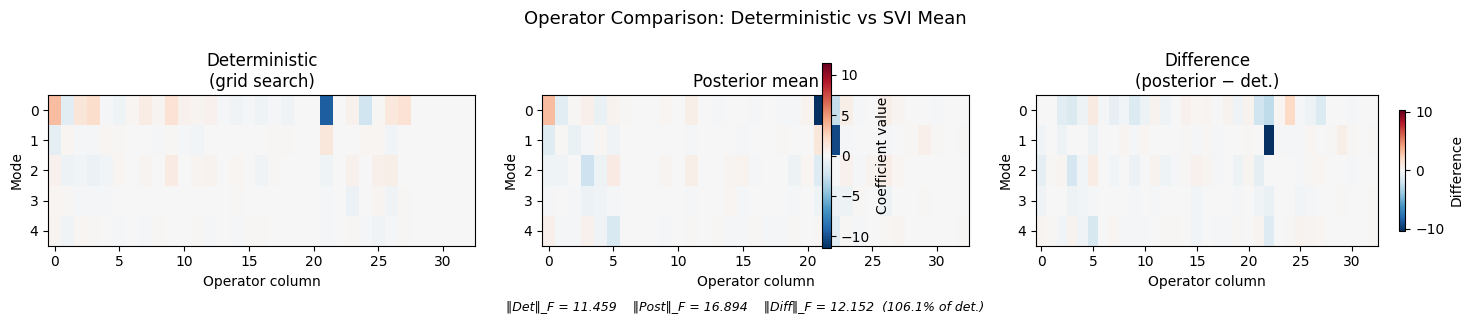

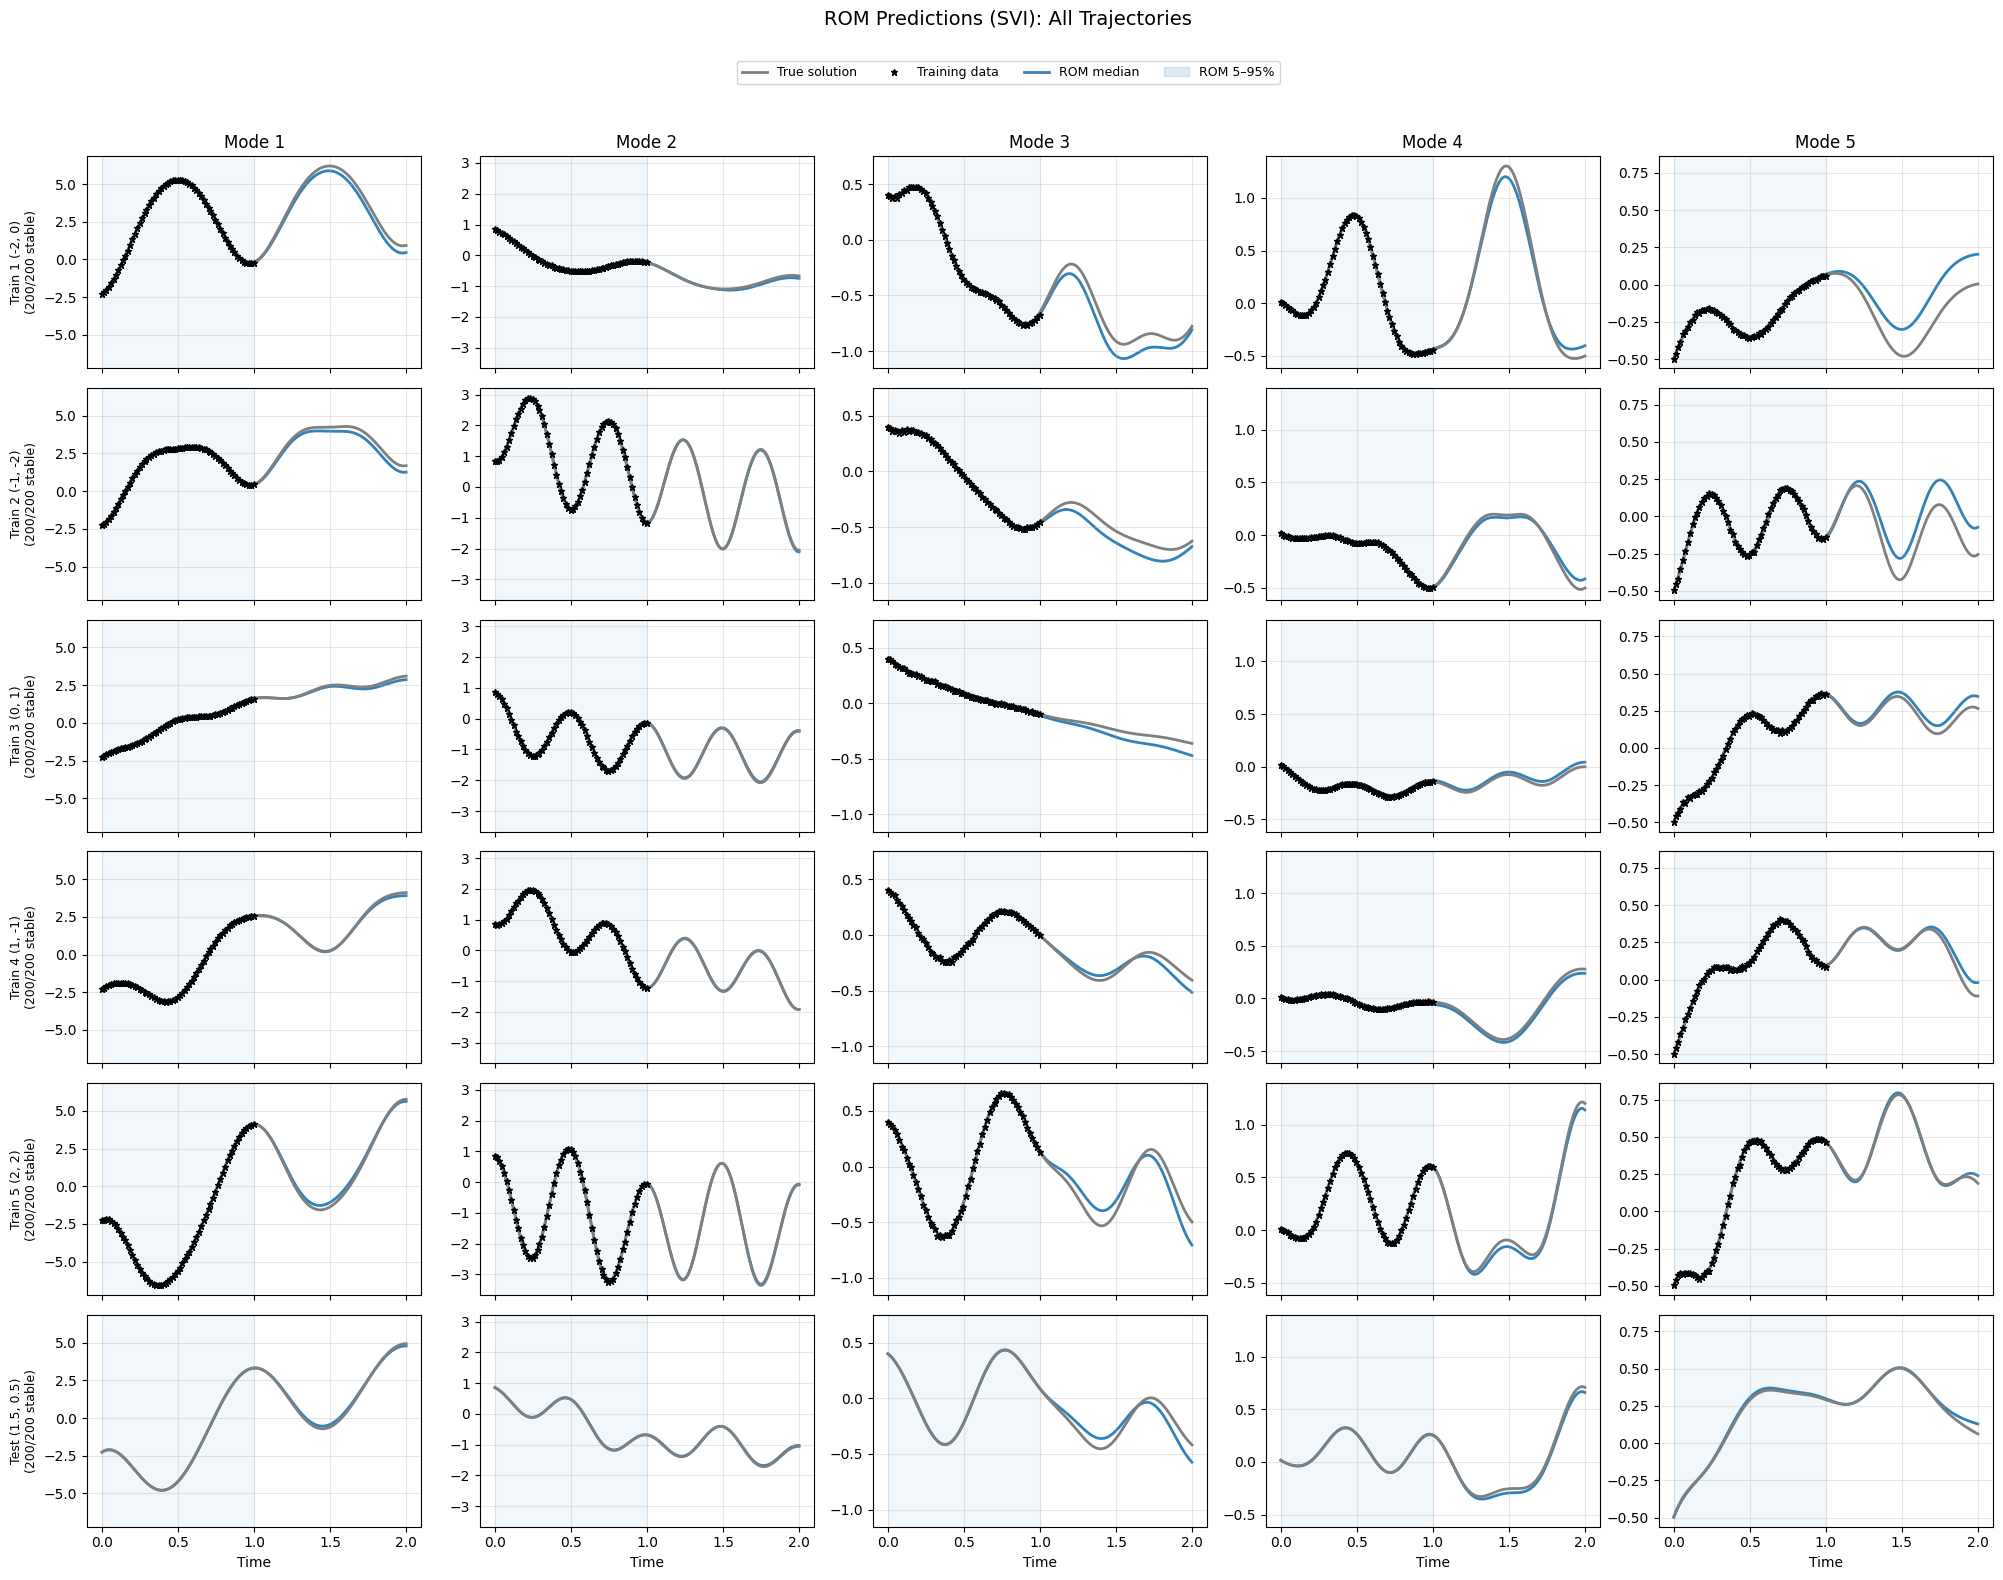

  Train 1 (-2, 0): mean err = 7.4137%, stable = 200
  Train 2 (-1, -2): mean err = 7.6412%, stable = 200
  Train 3 (0, 1): mean err = 4.7456%, stable = 200
  Train 4 (1, -1): mean err = 3.0848%, stable = 200
  Train 5 (2, 2): mean err = 3.7364%, stable = 200
  Test (1.5, 0.5): mean err = 3.2992%, stable = 200


In [ ]:
# === SVI Results ===
if RUN_SVI:
    svi_Os, svi_all_solves, svi_all_errors = _evaluate_and_plot(
        svi_result.samples, "SVI"
    )

In [ ]:
# Run MCMC (optional, more expensive)
if RUN_MCMC:
    # Initialize from SVI if requested and available
    init_values = None
    if USE_SVI_FOR_MCMC_INIT and RUN_SVI and 'svi_O_init' in dir() and svi_O_init is not None:
        init_values = {"O": svi_O_init}
        print(f"Initializing MCMC from SVI result (shape: {svi_O_init.shape})")
    else:
        print("MCMC will find its own starting point via NUTS adaptation")
    
    mcmc_result = run_mcmc(
        model=bayesian_opinf_model,
        rng_key=jax.random.PRNGKey(1),
        time_eval=time_eval,
        init_values=init_values,
        gamma=GAMMA3 if GAMMA3 else GAMMA,
        gamma2=GAMMA4 if GAMMA4 else GAMMA2,
        num_warmup=150,
        num_samples=200,
        num_chains=2,
        verbose=True
    )
    samples = mcmc_result.samples

### 5b. MCMC Results

In [ ]:
# === MCMC Results ===
if RUN_MCMC:
    mcmc_Os, mcmc_all_solves, mcmc_all_errors = _evaluate_and_plot(
        mcmc_result.samples, "MCMC"
    )

## 6. Results and Visualization

In [ ]:
# Check sample keys (debug)
print("Sample keys:", list(samples.keys())[:5], "...")
print()

# Generate ROM predictions on the full PREDICTION domain
# This tests both interpolation (within training span) and extrapolation (beyond)
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples,
    rom=rom,
    snapshots_compressed=snapshots_comp_first,
    time_eval=time_domain_eval_prediction,
    num_modes=NUM_MODES,
    num_pulls=200,
    input_func=first_input_func,
    data_scaler=data_scaler if USE_SCALED_DATA else None
)

print(f"Collected {len(Os)} operator samples")
print(f"Stable ROM solves: {len(rom_solves)} (on prediction domain [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}])")

Sample keys: ['O', 'X0_0', 'X0_1', 'X0_2', 'X0_3'] ...

Collected 200 operator samples
Stable ROM solves: 200 (on prediction domain [0, 2.0])


In [ ]:
# Operator posterior summary
O_mean = Os.mean(axis=0)
O_std = Os.std(axis=0)

print("Prior operator (first row):")
print(prior_operator[0, :5])
print("\nPosterior mean (first row):")
print(O_mean[0, :5])
print("\nPosterior std (first row):")
print(O_std[0, :5])

Prior operator (first row):
[ 3.49819016 -1.23809936  1.34853523  1.99896248 -0.25635946]

Posterior mean (first row):
[ 3.5041943  -1.1832242   0.16896021  0.5406629  -0.77406293]

Posterior std (first row):
[7.1525574e-07 2.0265579e-06 2.8312206e-07 6.5565109e-07 5.3644180e-07]


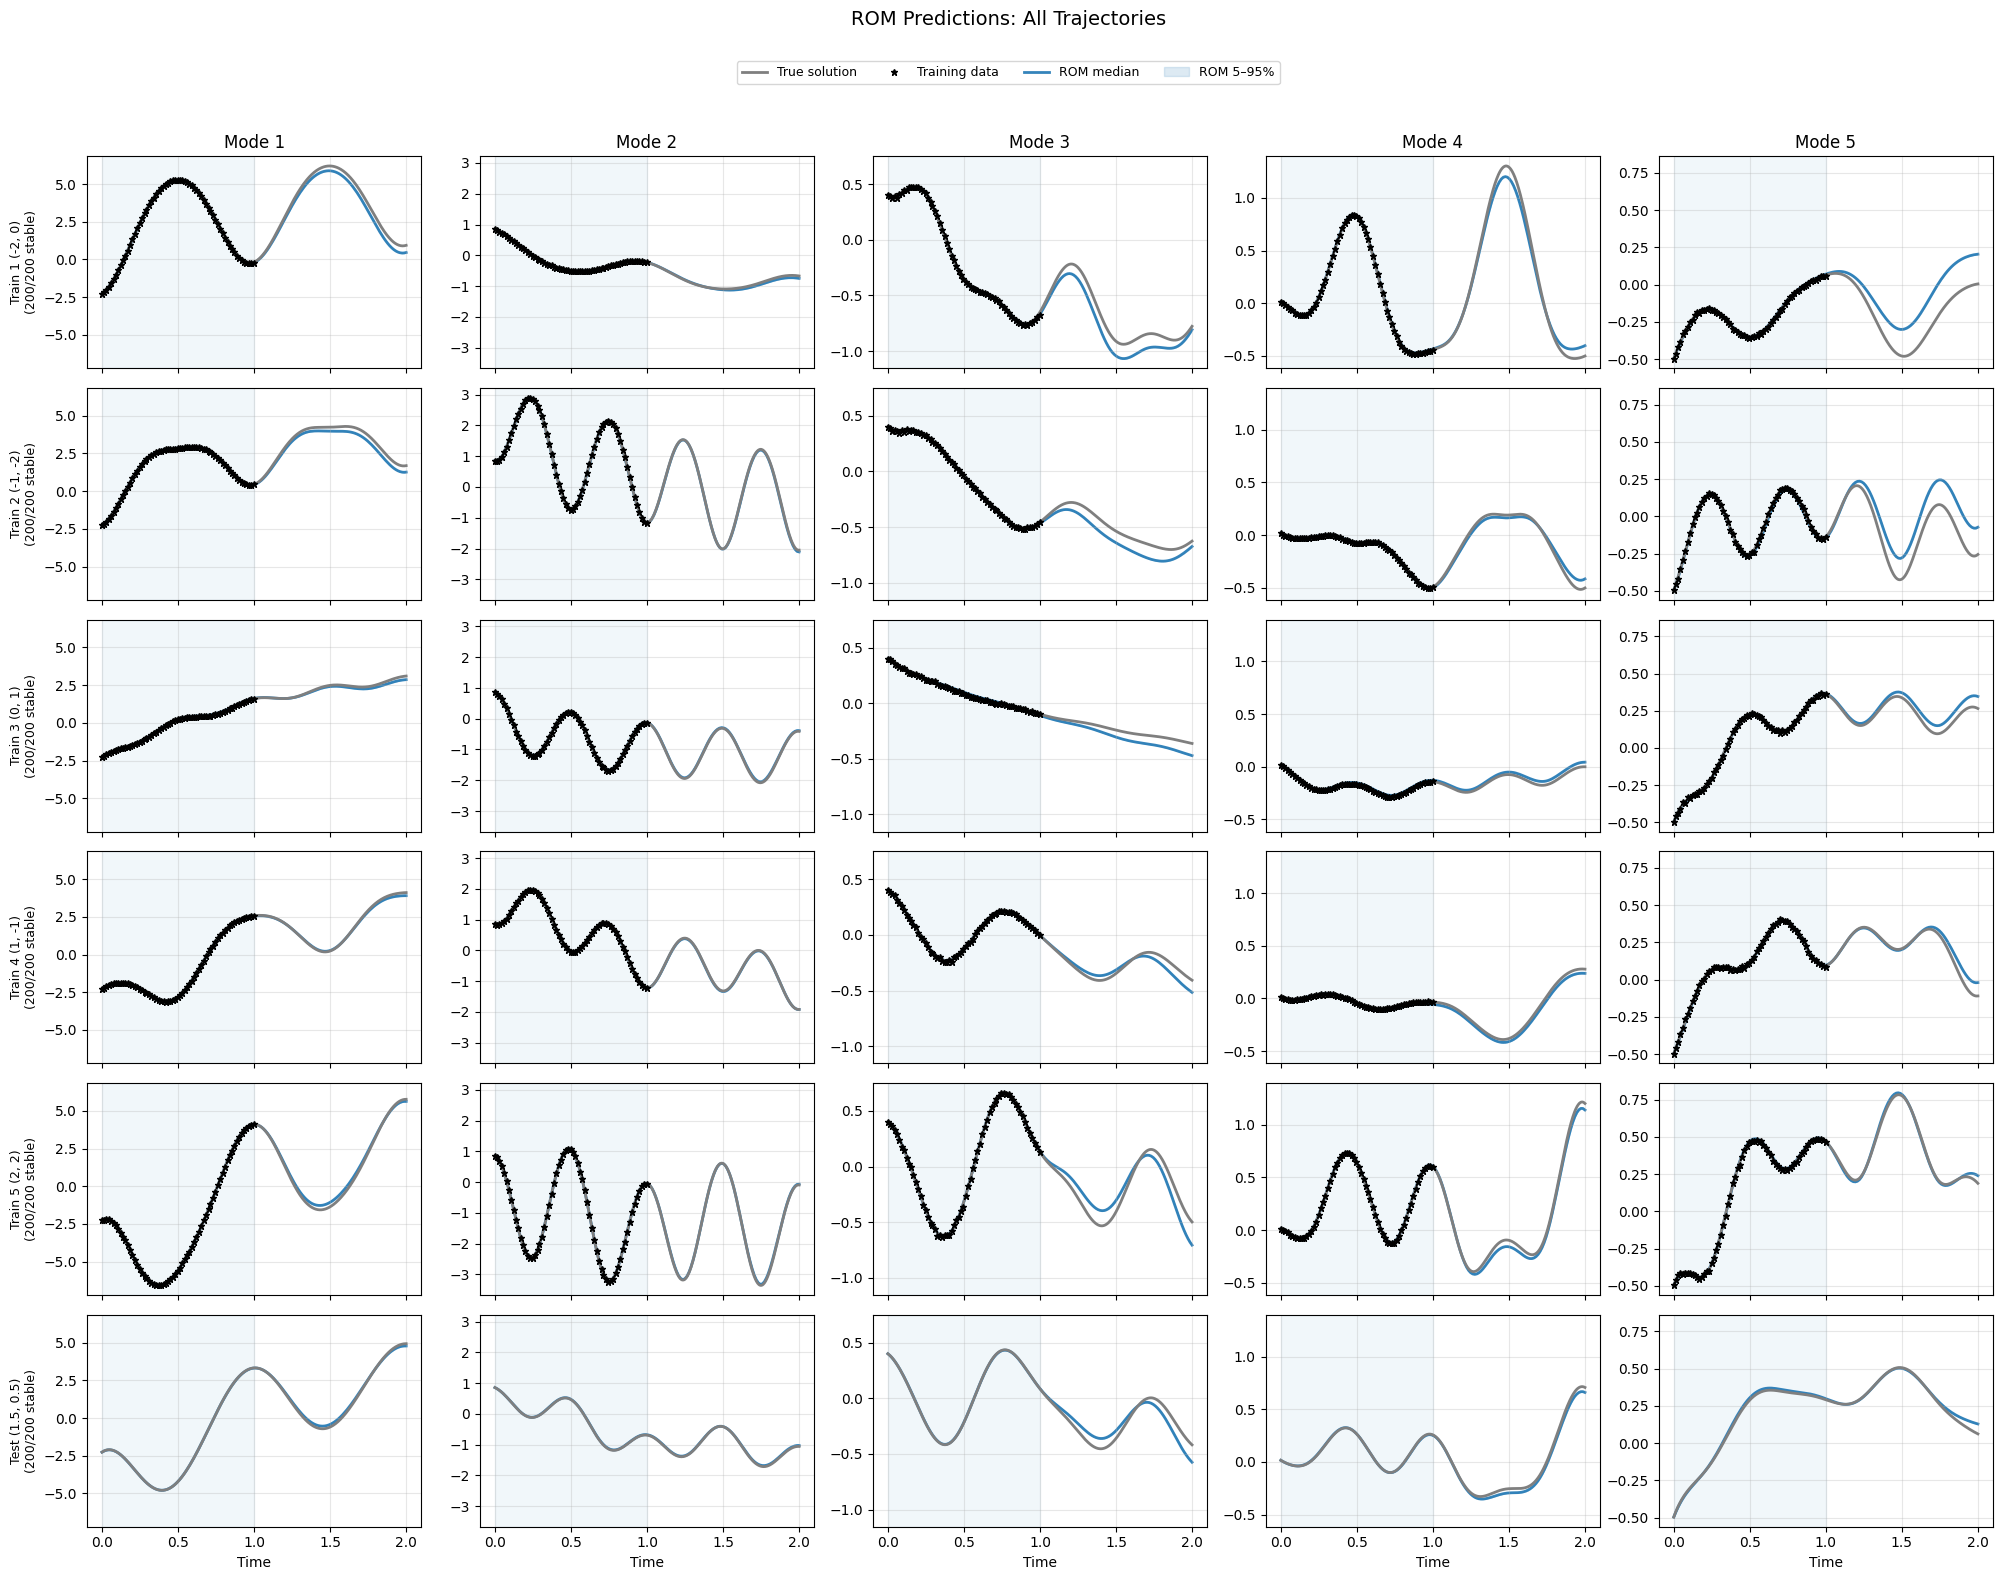

In [ ]:
# All-trajectory ROM predictions using HeatPlotter
import importlib
import heat_plotter
importlib.reload(heat_plotter)
from heat_plotter import HeatPlotter, compute_trajectory_errors

plotter = HeatPlotter(
    numPODmodes=NUM_MODES,
    time_domain_training=time_sampled,
    time_domain_prediction=time_domain_full,
    time_domain_eval_training=time_domain_eval_training,
    time_domain_eval_prediction=time_domain_eval_prediction,
    snapshots_training=snapshots_comp_first,
    snapshots_prediction=snapshots_comp_first,
)

# Build trajectory dicts for all training ICs + test IC
trajectories = []
for ic_idx in range(NUM_TRAIN_ICS):
    snap_start = ic_idx * NUM_SAMPLES
    snap_end = (ic_idx + 1) * NUM_SAMPLES
    snapshots_ic = snapshots_compressed[:, snap_start:snap_end]
    true_ic = basis.compress(all_true_states[ic_idx])
    trajectories.append({
        'q0': snapshots_ic[:, 0],
        'input_func': input_func_factory(train_params[ic_idx]),
        'snapshots': snapshots_ic,
        'time_snapshots': time_sampled,
        'true_compressed': true_ic,
        'time_true': time_domain_full,
        'label': f'Train {ic_idx+1} {train_params[ic_idx]}',
    })

# Add test trajectory (no training data)
trajectories.append({
    'q0': snapshots_test_compressed[:, 0],
    'input_func': input_func_factory(test_params),
    'snapshots': None,
    'time_snapshots': None,
    'true_compressed': snapshots_test_compressed,
    'time_true': time_domain_full,
    'label': f'Test {test_params}',
})

# Multi-trajectory plot (rows = trajectories, cols = modes)
# ROM evaluates on the full prediction domain — extrapolates beyond training span
fig, axes, all_rom_solves = plotter.multi_trajectory_plot(
    operator_samples=Os,
    rom=rom,
    trajectories=trajectories,
    time_eval=time_domain_eval_prediction,
    max_num_samples=200,
    training_span=TRAINING_SPAN,
)
plt.show()

In [ ]:
# Compute errors for all trajectories (training + test)
print("=" * 60)
print("TRAJECTORY ERRORS (vs projected FOM truth)")
print("=" * 60)

all_errors = {}
for i, (traj, rom_solves_i) in enumerate(zip(trajectories, all_rom_solves)):
    label = traj.get('label', f'Trajectory {i+1}')
    if len(rom_solves_i) > 0 and traj.get('true_compressed') is not None:
        errors = compute_trajectory_errors(
            rom_solves_i, traj['true_compressed'],
            time_domain_eval_prediction, traj['time_true'], NUM_MODES,
        )
        all_errors[label] = errors
        print(f"\n{label}:")
        print(f"  Mean relative error: {np.mean(errors):.4%}")
        print(f"  Std relative error:  {np.std(errors):.4%}")
        print(f"  Stable solves: {len(rom_solves_i)}")
    else:
        print(f"\n{label}: No stable ROM solutions")

TRAJECTORY ERRORS (vs projected FOM truth)

Train 1 (-2, 0):
  Mean relative error: 7.4137%
  Std relative error:  0.0000%
  Stable solves: 200

Train 2 (-1, -2):
  Mean relative error: 7.6412%
  Std relative error:  0.0000%
  Stable solves: 200

Train 3 (0, 1):
  Mean relative error: 4.7456%
  Std relative error:  0.0000%
  Stable solves: 200

Train 4 (1, -1):
  Mean relative error: 3.0848%
  Std relative error:  0.0000%
  Stable solves: 200

Train 5 (2, 2):
  Mean relative error: 3.7364%
  Std relative error:  0.0000%
  Stable solves: 200

Test (1.5, 0.5):
  Mean relative error: 3.2992%
  Std relative error:  0.0000%
  Stable solves: 200


## 7. Test Trajectory Generalization

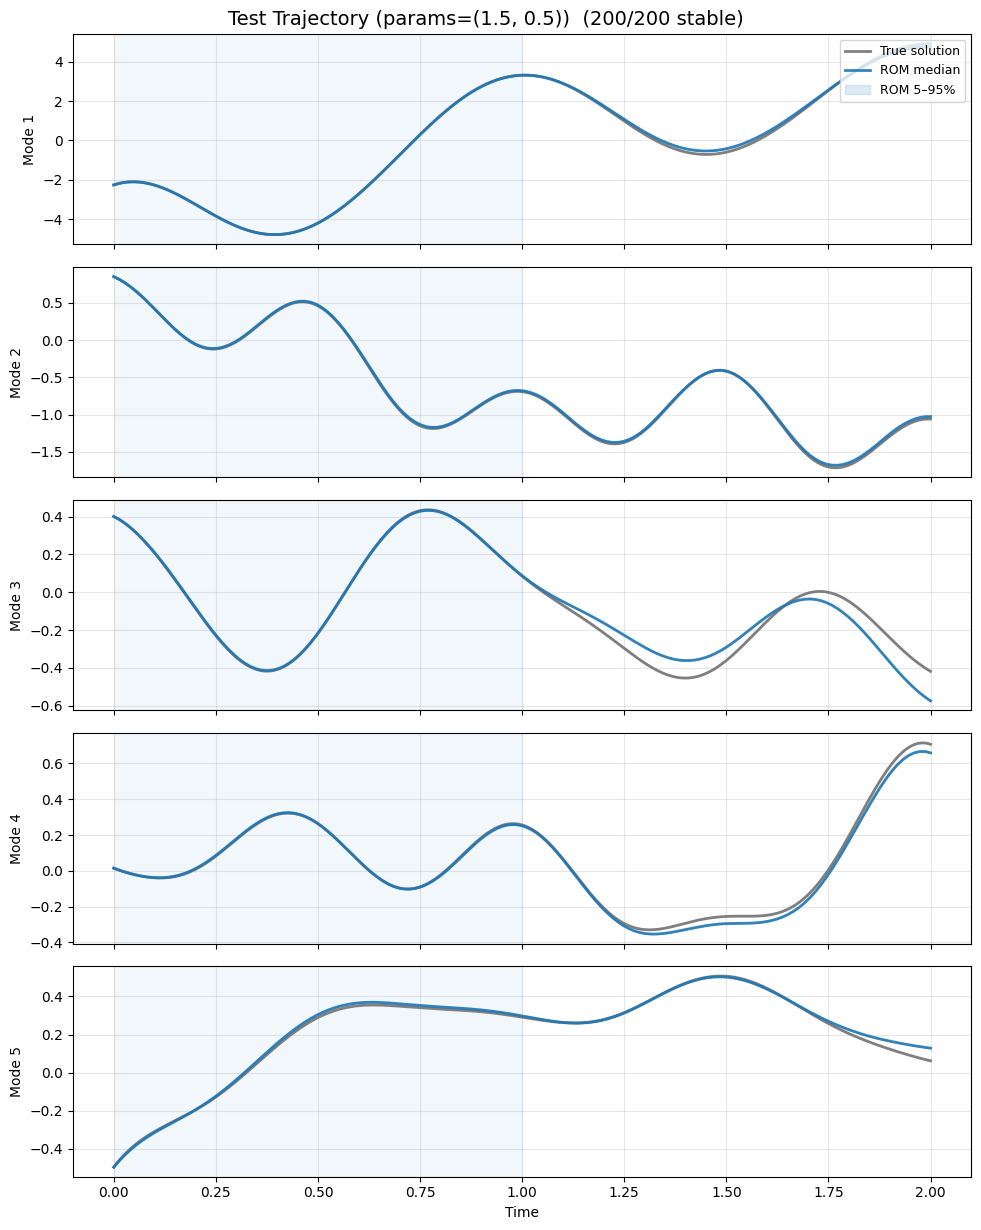


Test Trajectory Errors:
  Mean relative error: 3.2992%
  Std relative error:  0.0000%
  Stable solves: 200/200


In [ ]:
# Detailed view: Test trajectory (single-column, euler style)
fig, axes, test_rom_solves = plotter.single_trajectory_plot(
    operator_samples=Os,
    rom=rom,
    q0=snapshots_test_compressed[:, 0],
    time_eval=time_domain_eval_prediction,
    input_func=input_func_factory(test_params),
    true_compressed=snapshots_test_compressed,
    time_true=time_domain_full,
    title=f'Test Trajectory (params={test_params})',
    max_num_samples=200,
    training_span=TRAINING_SPAN,
)
plt.show()

# Test errors
if len(test_rom_solves) > 0:
    test_errors = compute_trajectory_errors(
        test_rom_solves, snapshots_test_compressed,
        time_domain_eval_prediction, time_domain_full, NUM_MODES,
    )
    print(f"\nTest Trajectory Errors:")
    print(f"  Mean relative error: {np.mean(test_errors):.4%}")
    print(f"  Std relative error:  {np.std(test_errors):.4%}")
    print(f"  Stable solves: {len(test_rom_solves)}/{min(len(Os), 200)}")

In [ ]:
# Summary
print("=" * 50)
print("EXPERIMENT SUMMARY: Cubic Heat Equation")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training ICs: {NUM_TRAIN_ICS}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Extrapolation: {PREDICTION_SPAN[1] - TRAINING_SPAN[1]:.2f}s beyond training")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Prior regularization: {result.best_reg:.1e}")
print(f"Prior error: {result.best_error:.4%}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
print(f"\nTrajectory Results:")
for label, errors in all_errors.items():
    print(f"  {label}:")
    print(f"    Mean error: {np.mean(errors):.4%}")
    print(f"    Stable: {len(errors)}/{min(len(Os), 200)}")

EXPERIMENT SUMMARY: Cubic Heat Equation
Operators: cAHBN
Modes: 5
Training ICs: 5
Training span: [0, 1.0]
Prediction span: [0, 2.0]
Extrapolation: 1.00s beyond training
Scaling: disabled
Prior regularization: 5.0e-01
Prior error: 1.1815%
Gamma (operator): 1.0
Gamma2 (ODE): 1.0
Guide: AutoDelta

Trajectory Results:
  Train 1 (-2, 0):
    Mean error: 7.4137%
    Stable: 200/200
  Train 2 (-1, -2):
    Mean error: 7.6412%
    Stable: 200/200
  Train 3 (0, 1):
    Mean error: 4.7456%
    Stable: 200/200
  Train 4 (1, -1):
    Mean error: 3.0848%
    Stable: 200/200
  Train 5 (2, 2):
    Mean error: 3.7364%
    Stable: 200/200
  Test (1.5, 0.5):
    Mean error: 3.2992%
    Stable: 200/200


## 8. Bayesian Model Diagnostics

Run post-inference diagnostics to check for common pitfalls:
- **Posterior correlation** — highly correlated parameters suggest redundancy or non-identifiability
- **Effective sample size (ESS)** — low ESS means samples are highly autocorrelated
- **Prior-posterior overlap** — checks if data is actually informing the posterior
- **Trace plots** — visual check for mixing and stationarity
- **Divergences & R-hat** — MCMC-specific convergence checks (when applicable)

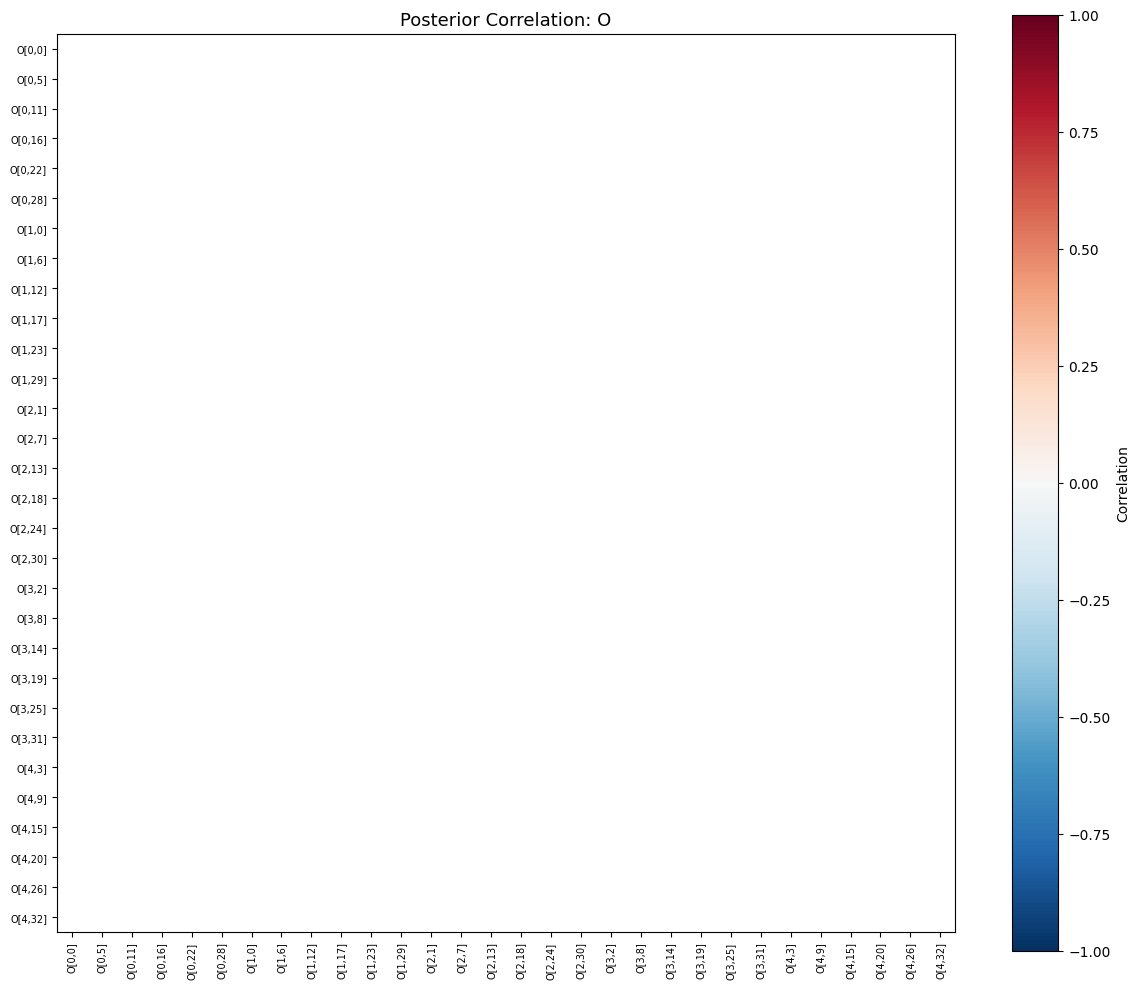

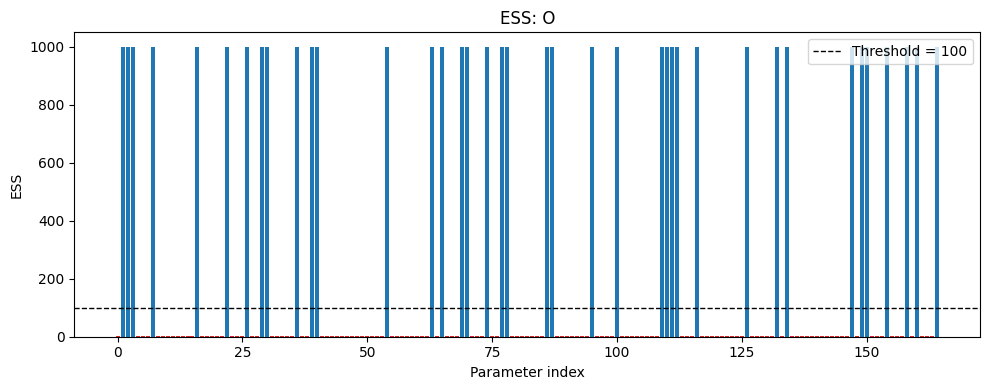

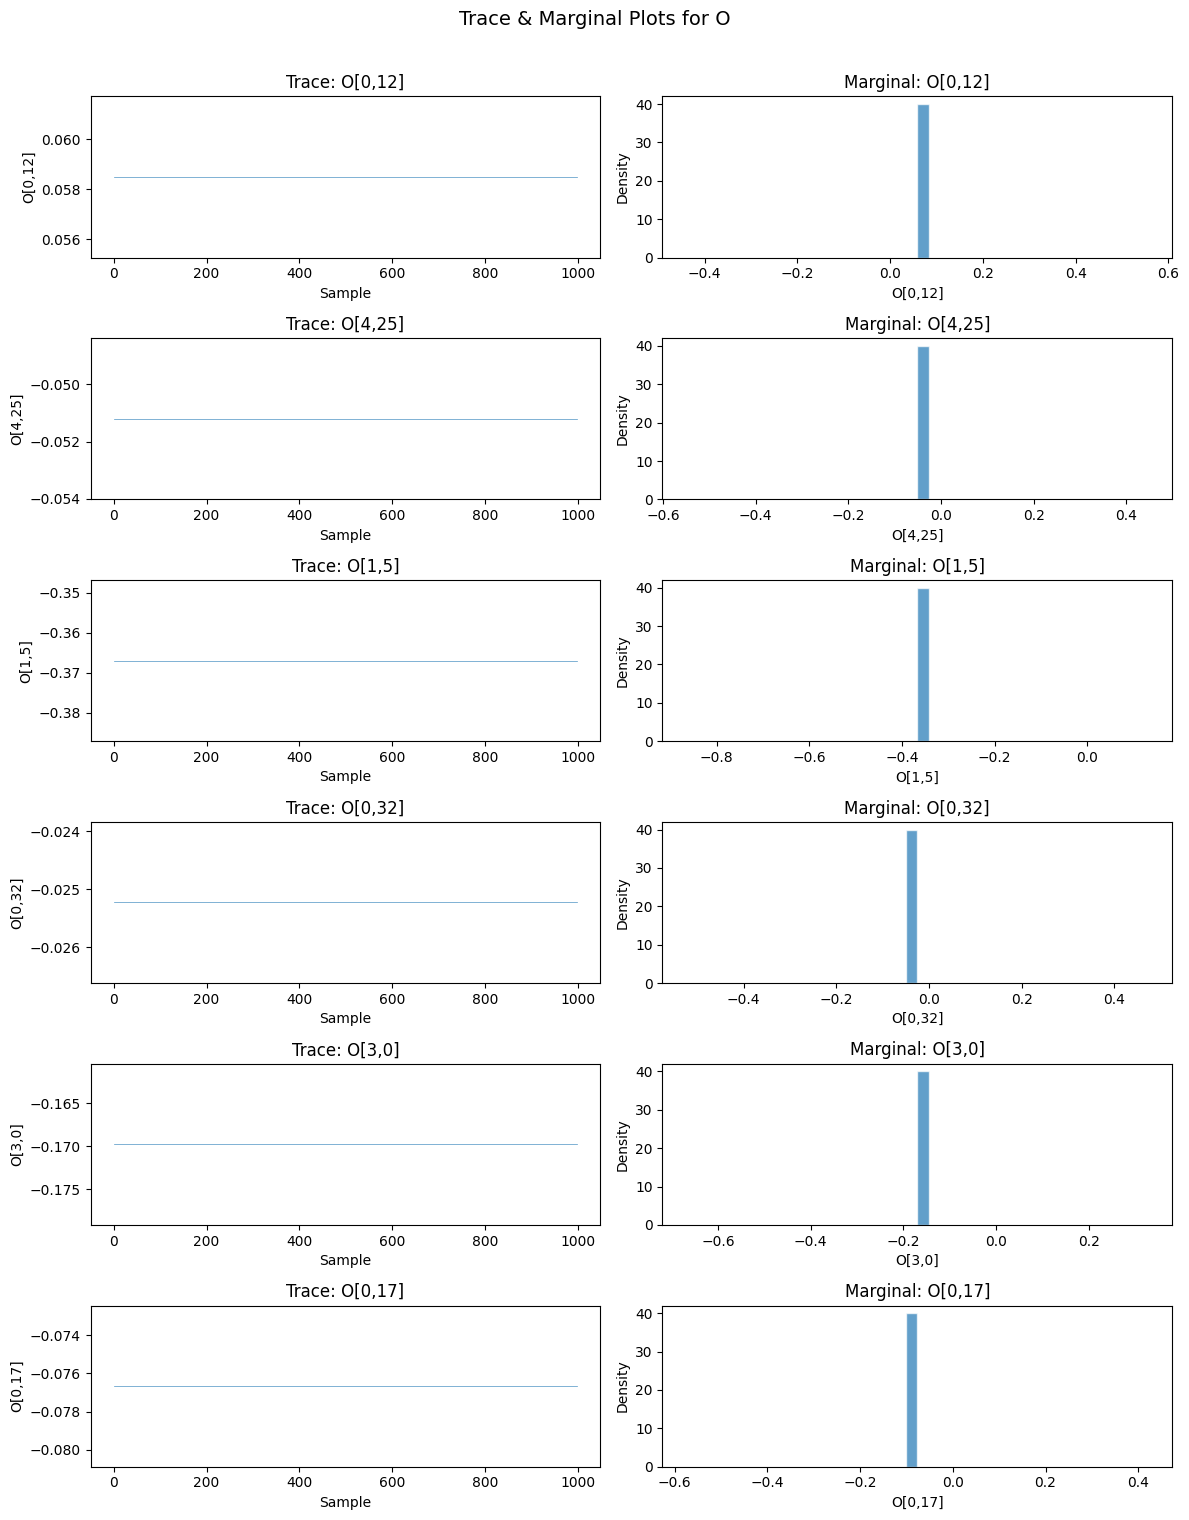

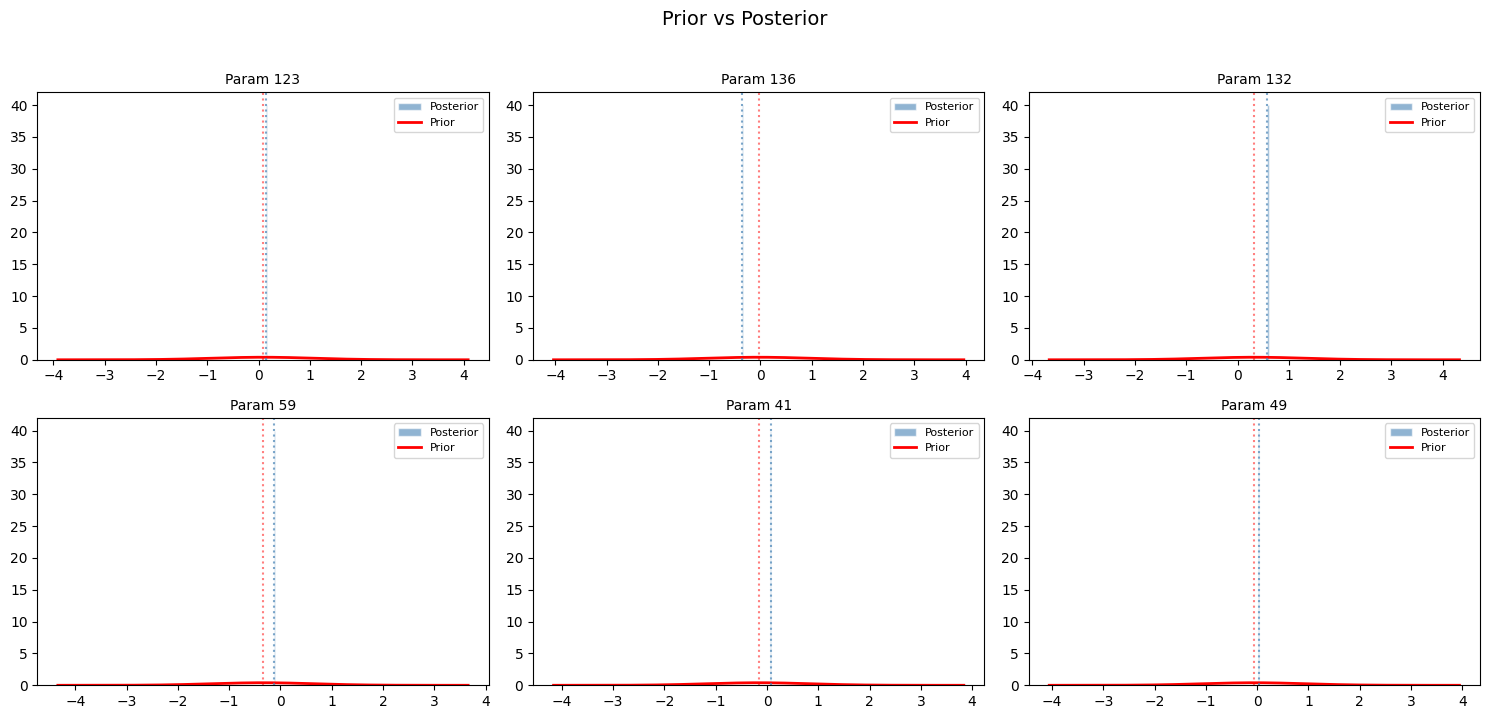

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  No high correlations detected (|r| > 0.9).

--- Effective Sample Size (ESS) ---
  Min ESS:  1.0
  Mean ESS: 237.1
  Max ESS:  1000.0
    O[0,0]: ESS = 1.0
    O[0,4]: ESS = 1.0
    O[0,5]: ESS = 1.0
    O[0,6]: ESS = 1.0
    O[0,8]: ESS = 1.0

--- Prior-Posterior Overlap ---
  O[3,4]: overlap = 3.13% [CHECK]
  O[2,11]: overlap = 3.06% [CHECK]
  O[1,21]: overlap = 3.22% [CHECK]
  O[2,4]: overlap = 3.13% [CHECK]
  O[4,8]: overlap = 3.21% [CHECK]

--- Summary Warnings ---
  1. 126 parameters have ESS < 100. Consider running longer chains or reparameterizing.
  2. Prior-posterior overlap for O[3,4] is 3% — prior may be misspecified (too narrow or wrong location).
  3. Prior-posterior overlap for O[2,11] is 3% — prior may be misspecified (too narrow or wrong location).
  4. Prior-posterior overlap for O[1,21] is 3% — prior may be misspecified (too narrow or wrong location).
  5. Prior-posterior overlap for O[2,4] is 3% — pr

In [ ]:
# Run full diagnostic suite
# Pass mcmc_result if MCMC was used, otherwise None
diag_report = run_diagnostics(
    samples=samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=mcmc_result if RUN_MCMC else None,
    samples_by_chain=None,  # Set to per-chain sample dicts if using multi-chain MCMC
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=True,
    plot=True,
)